# Build workflow graph with memory
We are going to build workflow graph with memory. But before building with memory, we try to build an example without memory.

## Build the workflow graph

### Define the tool functions

In [1]:
### mathematic function
def multiply(a: int, b: int) -> int:
    """Multiply a and b.

    Args:
        a: first int
        b: second int
    """
    return a * b

def divide(a: int, b: int) -> float:
    """Divide a and b.

    Args:
        a: first int
        b: second int
    """
    return a / b

def add(a: int, b: int) -> int:
    """Adds a and b.

    Args:
        a: first int
        b: second int
    """
    return a + b


def minus(a: int, b: int) -> int:
    """Minus a to b.

    Args:
        a: first int
        b: second int
    """
    return a - b

In [4]:
tools = [multiply, divide, add, minus]

### Define state object

In [3]:
from typing import TypedDict, Annotated
from langchain_core.messages import AnyMessage
from langgraph.graph.message import add_messages

class State(TypedDict):
    messages:Annotated[list[AnyMessage],add_messages]

### Define node function

In [5]:
from langchain_google_vertexai import ChatVertexAI

llm = ChatVertexAI(
    model_name="gemini-2.5-flash-lite",
    temperature=0.0
)

llm_with_tools=llm.bind_tools(tools)

In [9]:

def tool_calling_llm(state:State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

### Define workflow graph

In [10]:
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

In [11]:
graph_builder = StateGraph(State)

graph_builder.add_node("tool_calling_llm", tool_calling_llm)
graph_builder.add_node("tools", ToolNode(tools))

graph_builder.add_edge(START, "tool_calling_llm")
graph_builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition,
)
graph_builder.add_edge("tools","tool_calling_llm")

In [14]:
from IPython.display import Image, display

from langchain_core.messages import AIMessage, HumanMessage

## Workflow without memory
We can see how the workflow without memory response to sequential questions.

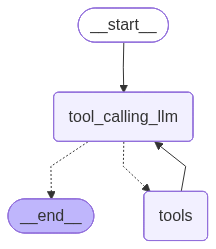

In [13]:
simple_graph = graph_builder.compile()

display(Image(simple_graph.get_graph().draw_mermaid_png()))

In [15]:
messages=simple_graph.invoke({"messages":HumanMessage(content="What is 5 plus 8")})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

What is 5 plus 8
================================== Ai Message ==================================
Tool Calls:
  add (56fc3d47-4ad6-4ca2-9f58-e2a9bc5d7e03)
 Call ID: 56fc3d47-4ad6-4ca2-9f58-e2a9bc5d7e03
  Args:
    a: 5.0
    b: 8.0
================================= Tool Message =================================
Name: add

13
================================== Ai Message ==================================

13


In [16]:
messages=[HumanMessage(content="Divide that by 5")]
messages=simple_graph.invoke({"messages":messages})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Divide that by 5
================================== Ai Message ==================================

I can help with that. What is the number you would like to divide by 5?


****
The workflow cannot memorise the content.

## Workflow with memory
Adding memory to  workflow graph is simple. We only add `langgraph.checkpoint.memory.MemorySaver` to `graph.compile()`

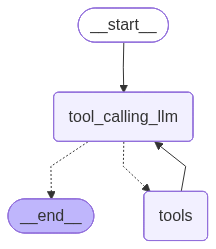

In [18]:
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()
memory_graph = graph_builder.compile(checkpointer=memory)

display(Image(memory_graph.get_graph().draw_mermaid_png()))

However, there are some change on calling `invoke()` function

In [20]:
config={"configurable":{"thread_id":"1"}}

messages=memory_graph.invoke({"messages":HumanMessage(content="What is 5 plus 8")}, config=config)
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

What is 5 plus 8
================================== Ai Message ==================================
Tool Calls:
  add (a8002aaf-6ecf-4619-a079-7b77d023ab93)
 Call ID: a8002aaf-6ecf-4619-a079-7b77d023ab93
  Args:
    a: 5.0
    b: 8.0
================================= Tool Message =================================
Name: add

13
================================== Ai Message ==================================

13


In [22]:
messages=[HumanMessage(content="Divide that by 5")]
messages=memory_graph.invoke({"messages":messages}, config=config)
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

What is 5 plus 8
================================== Ai Message ==================================
Tool Calls:
  add (a8002aaf-6ecf-4619-a079-7b77d023ab93)
 Call ID: a8002aaf-6ecf-4619-a079-7b77d023ab93
  Args:
    a: 5.0
    b: 8.0
================================= Tool Message =================================
Name: add

13
================================== Ai Message ==================================

13
================================ Human Message =================================

Divide that by 5
================================== Ai Message ==================================
Tool Calls:
  divide (9295d50a-5b80-4576-a3b9-82fa9e5399e4)
 Call ID: 9295d50a-5b80-4576-a3b9-82fa9e5399e4
  Args:
    a: 13.0
    b: 5.0
================================= Tool Message =================================
Name: divide

2.6
================================== Ai Message ==================================

2.6
